<a href="https://colab.research.google.com/github/mfaiz23/Churn-Prediction-OCTE/blob/main/03_modeling_octe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌲 NOTEBOOK 03 — PEMODELAN: BASELINE & PROPOSED OCTE
**Eksperimen 4: SMOTE Before Split + OCTE (Optimal Causal Decision Trees Ensemble)**

---
## Deskripsi
Notebook ini mengimplementasikan dua model utama:

**Model 1 — Baseline: Random Forest Classifier**
Model pembanding standar yang digunakan sebagai garis dasar performa.

**Model 2 — Proposed: Optimal Causal Decision Trees Ensemble (OCTE)**
Metode utama yang diusulkan, mengikuti algoritma dari paper:
> *Younas et al. (2022). "Optimal Causal Decision Trees Ensemble for Improved Prediction and Causal Inference." IEEE Access.*

---
## Cara Kerja OCTE (Sesuai Paper)

OCTE adalah varian dari **Generalized Random Forest (GRF)** yang diperkuat dengan prosedur seleksi pohon optimal:

1. **B sub-sample** diambil dari data training `L = (X, Y, W)` menggunakan bootstrap
2. **Causal Decision Tree** ditumbuhkan pada setiap sub-sample, dengan W (treatment) sebagai input
3. **Out-of-sample Standard Error** dihitung untuk setiap pohon pada data OOB (Out-of-Bag)
4. Pohon-pohon diurutkan berdasarkan OOB error dari terkecil ke terbesar
5. **Top-M pohon** terbaik dipilih dan dikombinasikan menjadi ensemble final
6. Ensemble final digunakan untuk prediksi kelas dan estimasi **CATE** (Conditional Average Treatment Effect)

```
CATE_i = E[Y | X_i, W=1] - E[Y | X_i, W=0]
```

## Prasyarat
> ✅ Notebook 02 harus sudah dijalankan. File `X_train_selected.csv`, `X_test_selected.csv`, `y_train.csv`, `y_test.csv` harus tersedia.

---
## Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/last_experiment'
print(f'✅ Google Drive mounted. Base path: {BASE_PATH}')

Mounted at /content/drive
✅ Google Drive mounted. Base path: /content/drive/MyDrive/last_experiment


---
## Cell 2 — Import Library

In [ ]:
import os
import pickle
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

print('✅ Semua library berhasil di-import.')

✅ Semua library berhasil di-import.


---
## Cell 3 — Load Data Hasil Feature Selection

In [ ]:
PROC_PATH = f'{BASE_PATH}/data/processed'

X_train = pd.read_csv(f'{PROC_PATH}/X_train_selected.csv')
X_test  = pd.read_csv(f'{PROC_PATH}/X_test_selected.csv')
y_train = pd.read_csv(f'{PROC_PATH}/y_train.csv')['churn value']
y_test  = pd.read_csv(f'{PROC_PATH}/y_test.csv')['churn value']

print('📊 Data berhasil dimuat:')
print(f'   X_train : {X_train.shape}  | y_train : {y_train.shape}')
print(f'   X_test  : {X_test.shape}   | y_test  : {y_test.shape}')
print(f'\n📋 Fitur yang tersedia ({X_train.shape[1]} kolom):')
print('   ' + ', '.join(X_train.columns.tolist()))

📊 Data berhasil dimuat:
   X_train : (8278, 16)  | y_train : (8278,)
   X_test  : (2070, 16)   | y_test  : (2070,)

📋 Fitur yang tersedia (16 kolom):
   tenure months, payment method_Electronic check, partner_Yes, paperless billing_Yes, monthly charges, gender_Male, total charges, tech support_Yes, online backup_Yes, internet service_Fiber optic, dependents_Yes, online security_Yes, senior citizen_Yes, device protection_Yes, multiple lines_Yes, treatment_w


---
## Cell 4 — Pisahkan Fitur dan Treatment untuk Model Kausal
Variabel `treatment_w` dipisahkan dari fitur prediktif karena ia berperan sebagai **variabel intervensi** dalam model kausal.

In [ ]:
# Pisahkan treatment dari fitur
W_train = X_train['treatment_w'].copy()
W_test  = X_test['treatment_w'].copy()

X_train_feat = X_train.drop(columns=['treatment_w'])
X_test_feat  = X_test.drop(columns=['treatment_w'])

print(f'✅ Variabel treatment berhasil dipisahkan.')
print(f'   X kovariat (train) : {X_train_feat.shape}')
print(f'   W treatment (train): {W_train.shape}')
print(f'\n🔬 Distribusi Treatment W di Training Set:')
w_dist = W_train.value_counts()
print(f'   W=0 (Kontrol/Non-Two Year): {w_dist.get(0, 0):,} ({w_dist.get(0, 0)/len(W_train)*100:.1f}%)')
print(f'   W=1 (Treated/Two Year)    : {w_dist.get(1, 0):,} ({w_dist.get(1, 0)/len(W_train)*100:.1f}%)')

✅ Variabel treatment berhasil dipisahkan.
   X kovariat (train) : (8278, 15)
   W treatment (train): (8278,)

🔬 Distribusi Treatment W di Training Set:
   W=0 (Kontrol/Non-Two Year): 6,812 (82.3%)
   W=1 (Treated/Two Year)    : 1,372 (16.6%)


---
## Cell 5 — MODEL BASELINE: Random Forest Classifier
Melatih Random Forest sebagai model pembanding. RF adalah model klasifikasi standar tanpa kemampuan estimasi efek kausal.

In [ ]:
print('🌲 Melatih Model Baseline: Random Forest Classifier...')
start_rf = time.time()

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_feat, y_train)

rf_time = time.time() - start_rf
rf_preds = rf_baseline.predict(X_test_feat)
rf_probs = rf_baseline.predict_proba(X_test_feat)[:, 1]

print(f'✅ Random Forest selesai dilatih dalam {rf_time:.2f} detik.')
print(f'   n_estimators : 100')
print(f'   max_depth    : 10')
print(f'   Akurasi awal : {accuracy_score(y_test, rf_preds)*100:.2f}%')

🌲 Melatih Model Baseline: Random Forest Classifier...
✅ Random Forest selesai dilatih dalam 0.85 detik.
   n_estimators : 100
   max_depth    : 10
   Akurasi awal : 86.23%


---
## Cell 6 — Cross-Validation Random Forest Baseline
Validasi silang 5-fold untuk mendapatkan estimasi performa yang lebih robust pada model baseline.

In [ ]:
print('🔄 Menjalankan 5-Fold Stratified Cross-Validation pada RF Baseline...')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_metrics = {}
for metric in ['accuracy', 'f1', 'roc_auc']:
    scores = cross_val_score(
        RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        X_train_feat, y_train, cv=skf, scoring=metric
    )
    cv_metrics[metric] = scores
    print(f'   {metric.upper():<12}: {scores.mean():.4f} ± {scores.std():.4f}  (fold scores: {[f"{s:.3f}" for s in scores]})')

print('\n✅ Cross-Validation RF Baseline selesai.')

🔄 Menjalankan 5-Fold Stratified Cross-Validation pada RF Baseline...
   ACCURACY    : 0.8649 ± 0.0068  (fold scores: ['0.867', '0.871', '0.865', '0.852', '0.870'])
   F1          : 0.8649 ± 0.0060  (fold scores: ['0.866', '0.869', '0.867', '0.853', '0.870'])
   ROC_AUC     : 0.9402 ± 0.0038  (fold scores: ['0.936', '0.943', '0.944', '0.935', '0.942'])

✅ Cross-Validation RF Baseline selesai.


---
## Cell 7 — DEFINISI KELAS OCTE
Implementasi manual **Optimal Causal Decision Trees Ensemble (OCTE)** sesuai pseudocode di paper Younas et al. (2022).

### Pseudocode Algoritma OCTE (Algorithm 1):
```
Input: L = (X, Y, W), B = jumlah sub-sample, M = jumlah pohon terbaik
for t = 1 → B:
    1. Ambil bootstrap sub-sample dari L
    2. Tumbuhkan causal tree menggunakan GRF
    3. Hitung OOB error (Standard Error)
    4. Simpan tree dan OOB error-nya
Urutkan pohon berdasarkan OOB SE (ascending)
Pilih Top-M pohon dengan SE terkecil
Gabungkan M pohon → OCTE Ensemble
Gunakan OCTE untuk: (a) prediksi Y_hat, (b) estimasi CATE
```

In [ ]:
class ManualOCTE:
    """
    Optimal Causal Decision Trees Ensemble (OCTE)
    Implementasi berdasarkan: Younas et al. (2022) IEEE Access.
    DOI: 10.1109/ACCESS.2022.3146406

    Parameters
    ----------
    n_trees : int
        B — jumlah pohon kausal awal yang ditumbuhkan
    top_m : int
        M — jumlah pohon terbaik yang dipilih ke ensemble final
    max_depth : int
        Kedalaman maksimum setiap decision tree
    random_state : int
        Seed untuk reprodusibilitas
    """

    def __init__(self, n_trees=150, top_m=40, max_depth=8, random_state=42):
        self.B = n_trees
        self.M = top_m
        self.max_depth = max_depth
        self.random_state = random_state
        self.selected_trees = []
        self.oob_errors_selected = []
        self.training_log = []

    def fit(self, X_data, y_data, w_data):
        """
        Langkah 1–8 dari Algorithm 1 (paper):
        Tumbuhkan B pohon, hitung OOB SE, pilih Top-M terbaik.
        """
        np.random.seed(self.random_state)
        all_trees = []
        oob_errors = []
        n_samples = len(X_data)

        X_arr = np.array(X_data, dtype=float)
        y_arr = np.array(y_data, dtype=float)
        w_arr = np.array(w_data, dtype=float)

        print(f'🚀 Memulai konstruksi {self.B} pohon kausal awal...')
        print(f'   Konfigurasi: B={self.B}, M={self.M}, max_depth={self.max_depth}')

        for b in range(self.B):
            # Step 1: Bootstrap sub-sampling (bagging)
            boot_idx = np.random.choice(n_samples, size=n_samples, replace=True)
            oob_mask = np.ones(n_samples, dtype=bool)
            oob_mask[np.unique(boot_idx)] = False
            oob_idx = np.where(oob_mask)[0]

            X_b, y_b, w_b = X_arr[boot_idx], y_arr[boot_idx], w_arr[boot_idx]

            # Step 2: Gabungkan X dan W sebagai input tree
            # Ini adalah inti dari causal tree: W dimasukkan sebagai kovariat
            X_tree_input = np.column_stack((X_b, w_b))

            # Step 3: Tumbuhkan causal decision tree
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=self.random_state + b
            )
            tree.fit(X_tree_input, y_b)

            # Step 4 & 5: Hitung OOB Standard Error
            if len(oob_idx) > 0:
                X_oob_input = np.column_stack((X_arr[oob_idx], w_arr[oob_idx]))
                oob_preds = tree.predict(X_oob_input)
                # MSE sebagai proxy Standard Error (sesuai paper)
                mse_oob = np.mean((y_arr[oob_idx] - oob_preds) ** 2)
            else:
                mse_oob = float('inf')  # Edge case: semua data masuk bootstrap

            all_trees.append(tree)
            oob_errors.append(mse_oob)

            if (b + 1) % 30 == 0:
                print(f'   Progress: {b+1}/{self.B} pohon ditumbuhkan '
                      f'(OOB MSE avg saat ini: {np.mean([e for e in oob_errors if e != float("inf")]):.4f})')

        # Step 9–10: Ranking & Seleksi Top-M
        top_indices = np.argsort(oob_errors)[:self.M]
        self.selected_trees = [all_trees[i] for i in top_indices]
        self.oob_errors_selected = [oob_errors[i] for i in top_indices]

        # Log training
        self.training_log = {
            'n_trees_grown': self.B,
            'n_trees_selected': self.M,
            'avg_oob_mse_all': np.mean([e for e in oob_errors if e != float('inf')]),
            'avg_oob_mse_selected': np.mean(self.oob_errors_selected),
            'best_oob_mse': min(self.oob_errors_selected),
            'worst_oob_mse': max(self.oob_errors_selected)
        }

        print(f'\n🎯 Seleksi OCTE Selesai!')
        print(f'   Pohon ditumbuhkan : {self.B}')
        print(f'   Pohon terpilih    : {self.M} (OOB MSE terendah)')
        print(f'   Avg OOB MSE (all) : {self.training_log["avg_oob_mse_all"]:.4f}')
        print(f'   Avg OOB MSE (sel) : {self.training_log["avg_oob_mse_selected"]:.4f}')

    def predict_proba(self, X_data):
        """
        Prediksi probabilitas pada kondisi kontrol (W=0).
        Rata-rata prediksi dari M pohon terpilih.
        """
        X_arr = np.array(X_data, dtype=float)
        X_control = np.column_stack((X_arr, np.zeros(len(X_arr))))

        accumulated = np.zeros(len(X_arr))
        for tree in self.selected_trees:
            accumulated += tree.predict(X_control)

        probs = accumulated / self.M
        # Clip ke [0, 1] untuk memastikan valid sebagai probabilitas
        return np.clip(probs, 0, 1)

    def predict_class(self, X_data, threshold=0.5):
        """Prediksi kelas biner dengan threshold tertentu."""
        probs = self.predict_proba(X_data)
        return (probs >= threshold).astype(int)

    def estimate_cate(self, X_data):
        """
        Estimasi Conditional Average Treatment Effect (CATE):
        CATE_i = E[Y | X_i, W=1] - E[Y | X_i, W=0]

        Positif: treatment meningkatkan probabilitas outcome
        Negatif: treatment menurunkan probabilitas outcome
        """
        X_arr = np.array(X_data, dtype=float)
        X_treat   = np.column_stack((X_arr, np.ones(len(X_arr))))
        X_control = np.column_stack((X_arr, np.zeros(len(X_arr))))

        cate_accum = np.zeros(len(X_arr))
        for tree in self.selected_trees:
            y1_hat = tree.predict(X_treat)
            y0_hat = tree.predict(X_control)
            cate_accum += (y1_hat - y0_hat)

        return cate_accum / self.M

print('✅ Kelas ManualOCTE berhasil didefinisikan.')

✅ Kelas ManualOCTE berhasil didefinisikan.


---
## Cell 8 — Pelatihan Model OCTE
Menjalankan algoritma OCTE: tumbuhkan B=150 pohon kausal, pilih Top-M=40 terbaik berdasarkan OOB MSE.

In [ ]:
# Hyperparameter OCTE
N_TREES  = 150  # @param {type:'integer'}  — B: jumlah pohon awal
TOP_M    = 40   # @param {type:'integer'}  — M: jumlah pohon terpilih
MAX_DEPTH = 8   # @param {type:'integer'}  — kedalaman maksimum pohon

print('🌲 Memulai pelatihan Proposed OCTE...')
start_octe = time.time()

octe_model = ManualOCTE(n_trees=N_TREES, top_m=TOP_M, max_depth=MAX_DEPTH)
octe_model.fit(X_train_feat, y_train, W_train)

octe_time = time.time() - start_octe
print(f'\n⏱️  Total waktu pelatihan OCTE: {octe_time:.2f} detik')

🌲 Memulai pelatihan Proposed OCTE...
🚀 Memulai konstruksi 150 pohon kausal awal...
   Konfigurasi: B=150, M=40, max_depth=8
   Progress: 30/150 pohon ditumbuhkan (OOB MSE avg saat ini: 0.1313)
   Progress: 60/150 pohon ditumbuhkan (OOB MSE avg saat ini: 0.1311)
   Progress: 90/150 pohon ditumbuhkan (OOB MSE avg saat ini: 0.1307)
   Progress: 120/150 pohon ditumbuhkan (OOB MSE avg saat ini: 0.1309)
   Progress: 150/150 pohon ditumbuhkan (OOB MSE avg saat ini: 0.1312)

🎯 Seleksi OCTE Selesai!
   Pohon ditumbuhkan : 150
   Pohon terpilih    : 40 (OOB MSE terendah)
   Avg OOB MSE (all) : 0.1312
   Avg OOB MSE (sel) : 0.1257

⏱️  Total waktu pelatihan OCTE: 5.89 detik


---
## Cell 9 — Prediksi dengan Model OCTE

In [ ]:
print('🔮 Menjalankan prediksi OCTE pada data uji...')

octe_preds  = octe_model.predict_class(X_test_feat)
octe_probs  = octe_model.predict_proba(X_test_feat)
cate_estimates = octe_model.estimate_cate(X_test_feat)

print(f'✅ Prediksi selesai.')
print(f'   Jumlah prediksi kelas  : {len(octe_preds)}')
print(f'   Jumlah estimasi CATE   : {len(cate_estimates)}')
print(f'\n📊 Statistik CATE (Conditional Average Treatment Effect):')
print(f'   Min CATE  : {cate_estimates.min():.4f}')
print(f'   Max CATE  : {cate_estimates.max():.4f}')
print(f'   Mean CATE : {cate_estimates.mean():.4f}  (ATE = Average Treatment Effect)')
print(f'   Std CATE  : {cate_estimates.std():.4f}')

ate_sign = 'menurunkan' if cate_estimates.mean() < 0 else 'meningkatkan'
print(f'\n💡 Interpretasi ATE: Kontrak Two Year rata-rata {ate_sign} '
      f'probabilitas churn sebesar {abs(cate_estimates.mean())*100:.2f}%')

🔮 Menjalankan prediksi OCTE pada data uji...
✅ Prediksi selesai.
   Jumlah prediksi kelas  : 2070
   Jumlah estimasi CATE   : 2070

📊 Statistik CATE (Conditional Average Treatment Effect):
   Min CATE  : -0.9451
   Max CATE  : 0.1060
   Mean CATE : -0.0846  (ATE = Average Treatment Effect)
   Std CATE  : 0.1067

💡 Interpretasi ATE: Kontrak Two Year rata-rata menurunkan probabilitas churn sebesar 8.46%


---
## Cell 10 — Perhitungan Metrik Error Kausal (MSE & RMSE CATE)
Evaluasi kualitas estimasi CATE menggunakan proxy: membandingkan estimasi CATE dengan outcome aktual yang disesuaikan dengan status treatment.

In [ ]:
# Proxy untuk evaluasi CATE: Aipw-style residual
# Untuk y biner: CATE residual = y_actual - predicted_potential_outcome sesuai W
y_test_arr = np.array(y_test, dtype=float)
w_test_arr = np.array(W_test, dtype=float)

# Prediksi outcome di bawah treatment dan kontrol
octe_y1_hat = np.array([
    tree.predict(np.column_stack((np.array(X_test_feat), np.ones(len(X_test_feat)))))
    for tree in octe_model.selected_trees
]).mean(axis=0)

octe_y0_hat = np.array([
    tree.predict(np.column_stack((np.array(X_test_feat), np.zeros(len(X_test_feat)))))
    for tree in octe_model.selected_trees
]).mean(axis=0)

# Pseudo-outcome sebagai target CATE ground-truth approximation
# tau_pseudo_i = (2W_i - 1) * (Y_i - (W_i * y1_hat + (1-W_i) * y0_hat))
y_pred_actual = w_test_arr * octe_y1_hat + (1 - w_test_arr) * octe_y0_hat
pseudo_outcome = (2 * w_test_arr - 1) * (y_test_arr - y_pred_actual)

# MSE dan RMSE CATE
cate_mse  = np.mean((cate_estimates - pseudo_outcome) ** 2)
cate_rmse = np.sqrt(cate_mse)
cate_mae  = np.mean(np.abs(cate_estimates - pseudo_outcome))

print('📐 Metrik Error Kausal (CATE Estimation Quality):')
print(f'   MSE  (CATE) : {cate_mse:.6f}')
print(f'   RMSE (CATE) : {cate_rmse:.6f}')
print(f'   MAE  (CATE) : {cate_mae:.6f}')
print(f'\n   ATE (Mean CATE): {cate_estimates.mean():.4f}')
print(f'   Std CATE       : {cate_estimates.std():.4f}')

# Simpan metrik kausal
causal_metrics = pd.DataFrame({
    'Metric': ['ATE', 'Std_CATE', 'Min_CATE', 'Max_CATE', 'CATE_MSE', 'CATE_RMSE', 'CATE_MAE'],
    'Value': [
        cate_estimates.mean(), cate_estimates.std(),
        cate_estimates.min(), cate_estimates.max(),
        cate_mse, cate_rmse, cate_mae
    ]
})
causal_metrics.to_csv(f'{BASE_PATH}/results/metrics/causal_metrics_octe.csv', index=False)
print('\n💾 Metrik kausal disimpan ke results/metrics/causal_metrics_octe.csv')

📐 Metrik Error Kausal (CATE Estimation Quality):
   MSE  (CATE) : 0.122395
   RMSE (CATE) : 0.349849
   MAE  (CATE) : 0.244967

   ATE (Mean CATE): -0.0846
   Std CATE       : 0.1067

💾 Metrik kausal disimpan ke results/metrics/causal_metrics_octe.csv


---
## Cell 11 — Perhitungan Metrik Klasifikasi Kedua Model

---

## Cell 12 — Visualisasi CATE & ATE Bootstrap
Visualisasi estimasi CATE individu dan distribusi bootstrap dari ATE untuk memahami efek rata-rata treatment secara lebih mendalam.

✅ Bootstrapping ATE selesai (1000 iterasi).
   ATE (Mean CATE)         : -0.0846
   95% CI ATE (Bootstrap)  : [-0.0893, -0.0799]


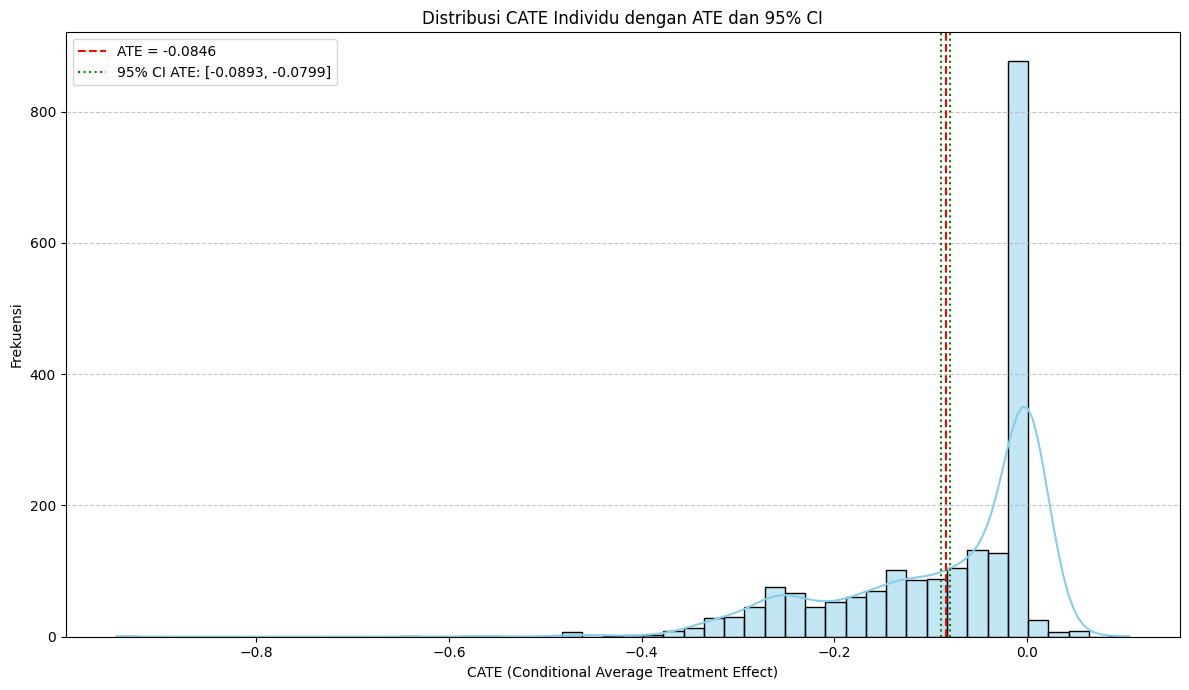

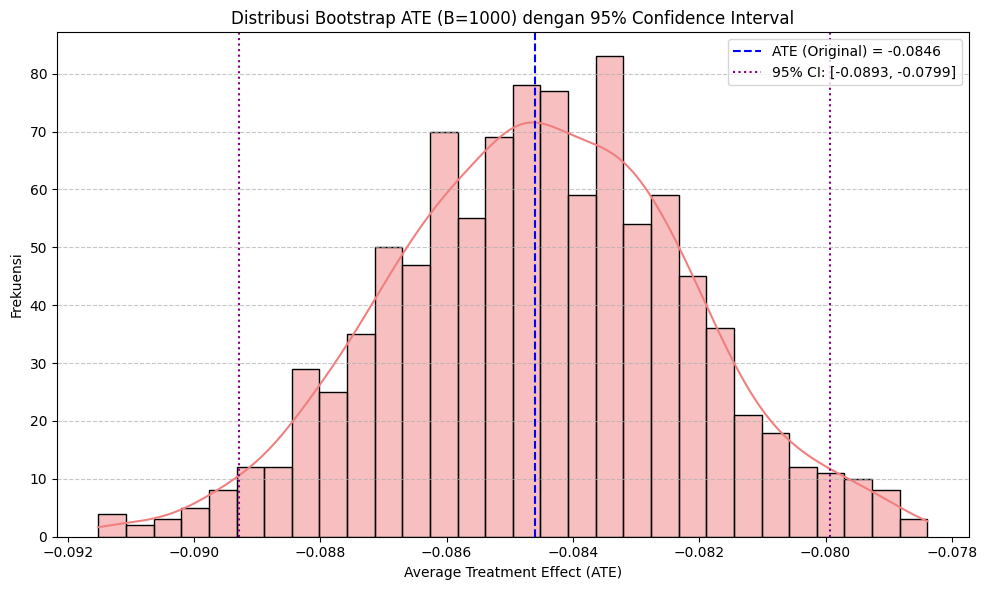

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Bootstrapping ATE untuk Confidence Interval ---

# Jumlah bootstrap samples
B = 1000
bootstrap_ates = []

for _ in range(B):
    # Resample cate_estimates dengan replacement
    # Gunakan np.random.choice untuk mengindeks cate_estimates
    sample_indices = np.random.choice(len(cate_estimates), size=len(cate_estimates), replace=True)
    resampled_cate = cate_estimates[sample_indices]
    bootstrap_ates.append(np.mean(resampled_cate))

# Hitung ATE dan 95% Confidence Interval dari bootstrap
ate_mean = np.mean(cate_estimates) # ATE dari estimasi asli
ate_ci_lower = np.percentile(bootstrap_ates, 2.5)
ate_ci_upper = np.percentile(bootstrap_ates, 97.5)

print(f'✅ Bootstrapping ATE selesai ({B} iterasi).')
print(f'   ATE (Mean CATE)         : {ate_mean:.4f}')
print(f'   95% CI ATE (Bootstrap)  : [{ate_ci_lower:.4f}, {ate_ci_upper:.4f}]')

# --- 2. Plot CATE Individu dengan Interval ATE ---

plt.figure(figsize=(12, 7))
sns.histplot(cate_estimates, kde=True, color='skyblue', bins=50)
plt.axvline(ate_mean, color='red', linestyle='--', label=f'ATE = {ate_mean:.4f}')
plt.axvline(ate_ci_lower, color='green', linestyle=':', label=f'95% CI ATE: [{ate_ci_lower:.4f}, {ate_ci_upper:.4f}]')
plt.axvline(ate_ci_upper, color='green', linestyle=':')

plt.title('Distribusi CATE Individu dengan ATE dan 95% CI')
plt.xlabel('CATE (Conditional Average Treatment Effect)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 3. Plot Distribusi Bootstrap ATE ---

plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_ates, kde=True, color='lightcoral', bins=30)
plt.axvline(ate_mean, color='blue', linestyle='--', label=f'ATE (Original) = {ate_mean:.4f}')
plt.axvline(ate_ci_lower, color='purple', linestyle=':', label=f'95% CI: [{ate_ci_lower:.4f}, {ate_ci_upper:.4f}]')
plt.axvline(ate_ci_upper, color='purple', linestyle=':')

plt.title(f'Distribusi Bootstrap ATE (B={B}) dengan 95% Confidence Interval')
plt.xlabel('Average Treatment Effect (ATE)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Hitung semua metrik klasifikasi
metrics_raw = {
    'Model'    : ['Random Forest Baseline', 'Proposed OCTE'],
    'Accuracy' : [accuracy_score(y_test, rf_preds),    accuracy_score(y_test, octe_preds)],
    'Precision': [precision_score(y_test, rf_preds),   precision_score(y_test, octe_preds)],
    'Recall'   : [recall_score(y_test, rf_preds),      recall_score(y_test, octe_preds)],
    'F1-Score' : [f1_score(y_test, rf_preds),          f1_score(y_test, octe_preds)],
    'AUC-ROC'  : [roc_auc_score(y_test, rf_probs),     roc_auc_score(y_test, octe_probs)]
}

metrics_pct = {
    'Model'    : metrics_raw['Model'],
    'Accuracy' : [f'{v*100:.2f}%' for v in metrics_raw['Accuracy']],
    'Precision': [f'{v*100:.2f}%' for v in metrics_raw['Precision']],
    'Recall'   : [f'{v*100:.2f}%' for v in metrics_raw['Recall']],
    'F1-Score' : [f'{v*100:.2f}%' for v in metrics_raw['F1-Score']],
    'AUC-ROC'  : [f'{v*100:.2f}%' for v in metrics_raw['AUC-ROC']]
}

metrics_df = pd.DataFrame(metrics_pct)
metrics_df.to_csv(f'{BASE_PATH}/results/metrics/classification_performance.csv', index=False)

# Tampilkan dashboard
print('\n' + '='*70)
print('     📊 DASHBOARD PERFORMA KLASIFIKASI KEDUA MODEL')
print('='*70)
print(f'   {"Metrik":<15} {"RF Baseline":>20} {"Proposed OCTE":>20}')
print('-'*60)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    print(f'   {metric:<15} {metrics_pct[metric][0]:>20} {metrics_pct[metric][1]:>20}')
print('='*70)
print('💾 Metrik klasifikasi disimpan ke results/metrics/classification_performance.csv')


     📊 DASHBOARD PERFORMA KLASIFIKASI KEDUA MODEL
   Metrik                   RF Baseline        Proposed OCTE
------------------------------------------------------------
   Accuracy                      86.23%               85.65%
   Precision                     85.58%               84.81%
   Recall                        87.15%               86.86%
   F1-Score                      86.36%               85.82%
   AUC-ROC                       94.01%               93.05%
💾 Metrik klasifikasi disimpan ke results/metrics/classification_performance.csv


---
## Cell 12 — Simpan Prediksi & Model ke Google Drive

In [ ]:
# Simpan prediksi lengkap
predictions_df = pd.DataFrame({
    'Actual_Churn'  : np.array(y_test),
    'W_Treatment'   : np.array(W_test),
    'RF_Pred_Class' : rf_preds,
    'RF_Prob'       : rf_probs,
    'OCTE_Pred_Class': octe_preds,
    'OCTE_Prob'     : octe_probs,
    'CATE_Estimate' : cate_estimates
})
predictions_df.to_csv(f'{BASE_PATH}/results/predictions/octe_predictions.csv', index=False)

# Simpan model OCTE
MODEL_PATH = f'{BASE_PATH}/results/models/octe_manual_model.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(octe_model, f)

# Simpan model RF Baseline
RF_PATH = f'{BASE_PATH}/results/models/rf_baseline_model.pkl'
with open(RF_PATH, 'wb') as f:
    pickle.dump(rf_baseline, f)

print('💾 Seluruh artefak pemodelan berhasil disimpan:')
print(f'   → results/predictions/octe_predictions.csv')
print(f'   → results/models/octe_manual_model.pkl')
print(f'   → results/models/rf_baseline_model.pkl')
print('\n✅ Notebook 03 selesai. Lanjutkan ke Notebook 04: Evaluasi & Visualisasi.')

💾 Seluruh artefak pemodelan berhasil disimpan:
   → results/predictions/octe_predictions.csv
   → results/models/octe_manual_model.pkl
   → results/models/rf_baseline_model.pkl

✅ Notebook 03 selesai. Lanjutkan ke Notebook 04: Evaluasi & Visualisasi.
